#### POD NOTEBOOK

This notebook applies POD-coupled FFD to a geometry and illustrates various reconstruction aspects.

In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import os
import random

from numpy import linalg as LA
from scipy.stats import qmc

from aero_optim.geom import split_profile
from aero_optim.ffd.ffd import FFD_2D
from aero_optim.mf_sm.mf_models import get_sampler

from functools import partial
import multiprocessing as mp
from collections import OrderedDict
from typing import Tuple, List, Union
import numpy.random as rng

OD = OrderedDict  # Type alias

# Define function to extract m and theta from tecplot file
def extract_data_from_tec(file_path, zone_name="NURB_Profil_gestaf0"):
    m_values = []
    theta_values = []
    in_zone = False

    with open(file_path, 'r') as file:
        for line in file:
            if f'ZONE T="{zone_name}"' in line:
                in_zone = True  # Start reading the data for the desired zone
            elif in_zone and line.strip().startswith("ZONE"):
                in_zone = False  # Stop reading after the zone ends
            elif in_zone:
                # Extract m and theta from the current line (first two columns)
                try:
                    values = line.split()
                    m_values.append(float(values[0]))
                    theta_values.append(float(values[1]))
                except ValueError:
                    continue  # Skip any lines that don't contain valid float values
    
    # Remove duplicate last point (first and last points are identical in tecplot files)
    m_array = np.array(m_values)
    theta_array = np.array(theta_values)
    if len(m_array) > 1 and np.allclose(m_array[0], m_array[-1]) and np.allclose(theta_array[0], theta_array[-1]):
        m_array = m_array[:-1]
        theta_array = theta_array[:-1]
    
    return m_array, theta_array

def read_progen_input(path: str) -> Tuple[List[str], OD]:
    """
    Legge il file `progen.input`, salva le prime 3 righe in `header`
    e il resto in un OrderedDict `entries`.
    - Commenti (linee che iniziano con '#' o '!') e linee vuote sono conservate
      come chiavi speciali '__comment_N' o '__blank_N' con valore = riga originale.
    - Linee con '=' vengono parse come key = value (split sulla prima '=').
    - Altre linee vengono parse come "key [value...]" (primo token = key, resto = value).
    - Se una chiave appare più volte, il valore viene salvato come lista di (sep, value) tuples per preservare il separatore.
    Ritorna (header_lines, entries).
    """
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    header = [lines[i].rstrip('\n') for i in range(min(3, len(lines)))]
    rest = lines[3:] if len(lines) > 3 else []

    # store entries as OrderedDict[key] = (sep, value) or list of (sep, value)
    entries: OD[str, Union[Tuple[Union[str, None], str], List[Tuple[Union[str, None], str]]]] = OrderedDict()
    comment_idx = 0
    blank_idx = 0

    for raw in rest:
        line = raw.rstrip('\n')
        stripped = line.lstrip()
        if stripped == '':
            blank_idx += 1
            entries[f'__blank_{blank_idx}'] = ''  # rappresenta una linea vuota
            continue
        if stripped.startswith('#') or stripped.startswith('!'):
            comment_idx += 1
            entries[f'__comment_{comment_idx}'] = line
            continue

        # detect separator to preserve formatting: '=' or whitespace
        if '=' in line:
            key, val = line.split('=', 1)
            sep = '='
            key = key.strip()
            val = val.strip()
        else:
            parts = line.split(None, 1)
            sep = None
            key = parts[0].strip()
            val = parts[1].strip() if len(parts) > 1 else ''

        item = (sep, val)
        if key in entries:
            existing = entries[key]
            if isinstance(existing, list):
                existing.append(item)
            else:
                entries[key] = [existing, item]
        else:
            entries[key] = item

    return header, entries


def write_progen_input(out_dir: str, header: List[str], entries: OD, input_dict: dict = None) -> None:
    """
    Scrive su file con lo stesso formato di progen.input:
    - Scrive le prime 3 righe (header) così come sono.
    - Poi scrive le entries nell'ordine dato:
      * '__blank_N' -> riga vuota
      * '__comment_N' -> riga commento così com'è
      * key -> 'key = value' o 'key value' a seconda del separatore originale
    out_dir must be a directory path; the function will create it if needed and write 'progen.input' inside.
    """
    import os
    os.makedirs(out_dir, exist_ok=True)
    out_file = os.path.join(out_dir, 'progen.input')

    with open(out_file, 'w', encoding='utf-8') as f:
        # header
        for i in range(3):
            line = header[i] if i < len(header) else ''
            f.write(line.rstrip('\n') + '\n')

        # body
        for key, val in entries.items():
            if key.startswith('__blank_'):
                f.write('\n')
            elif key.startswith('__comment_'):
                # val contiene la riga così com'era
                f.write(val.rstrip('\n') + '\n')
            else:
                # entries store either (sep, value) or list of (sep, value)
                items = val if isinstance(val, list) else [val]

                # If input_dict provided and key present in input_dict, replace values
                if input_dict is not None and key in input_dict:
                    ov = input_dict[key]
                    # choose separator preference from existing items (prefer first item's sep)
                    first_sep = items[0][0] if items else None
                    if isinstance(ov, list):
                        # build items list from input_dict list
                        items = [(first_sep, str(x)) for x in ov]
                    else:
                        items = [(first_sep, str(ov))]

                for sep, v in items:
                    if sep == '=':
                        f.write(f"{key} = {v}\n")
                    else:
                        # write with single space separator to mimic original whitespace format
                        if v == '':
                            f.write(f"{key}\n")
                        else:
                            f.write(f"{key} {v}\n")

def generate_design_variants(bounds: dict, header: List[str], entries: OD, variant_index: int, out_base_dir: str, seed: int | None = None) -> str:
    """Generate a single design parameter dict by uniform sampling each bound in `bounds` and
    immediately write a `progen.input` for that variant using `write_progen_input`.

    Args:
        bounds: mapping key -> [low, high] or list of single-key dicts
        header, entries: parsed progen input used as template
        variant_index: index of this variant (1-based)
        out_base_dir: parent directory where `test_i` folder will be created
        seed: optional RNG seed

    Returns:
        Path to the directory written (out_base_dir/test_i)
    """
    os.makedirs(out_base_dir, exist_ok=True)

    # initialize RNG using provided seed (None -> random entropy)
    if seed is not None:
        np.random.seed(seed + variant_index)  # different seed per variant

    variant = {}
    # Handle both dict and list of single-key dicts
    bounds_dict = bounds
    if isinstance(bounds, list):
        bounds_dict = {}
        for b in bounds:
            if isinstance(b, dict):
                bounds_dict.update(b)
    
    for k, (lo, hi) in bounds_dict.items():
        # Uniform random sampling
        variant[k] = rng.uniform(float(lo), float(hi))

    print(variant)

    out_dir = os.path.join(out_base_dir, f'test_{variant_index}')
    write_progen_input(out_dir, header, entries, input_dict=variant)
    print(f'Generated variant {variant_index}: {variant}')

    return out_dir

def _simulate_single_variant(args):
    """
    Worker function to simulate a single variant. Designed to be used with multiprocessing.
    
    Args:
        args: tuple containing (i, bounds, header, entries, out_base_dir, blade_generator_path, seed)
    
    Returns:
        tuple: (i, success, data_2d) where:
            - i: variant index
            - success: boolean indicating if simulation was successful
            - data_2d: extracted data as numpy array or empty array if failed
    """
    i, bounds, header, entries, out_base_dir, blade_generator_path, seed = args
    
    variant_dir = os.path.join(out_base_dir, f'test_{i}')
    output_file = os.path.join(variant_dir, 'Output', 'Profile_mergedGestaf.tec')
    
    # Check if output already exists
    if os.path.exists(output_file):
        print(f'  Variant {i}: Output already exists, skipping generation and simulation')
        try:
            m, theta = extract_data_from_tec(output_file)
            data_2d = np.column_stack((m, theta))
            print(f'  Extracted existing data from {variant_dir}: shape {data_2d.shape}')
            return (i, True, data_2d)
        except Exception as e:
            print(f'  Error extracting existing data from {output_file}: {e}')
            return (i, False, np.array([]))
    else:
        # Generate variant and run simulation
        print(f'  Variant {i}: Generating progen.input...')
        try:
            # variant_dir = generate_design_variants(bounds, header, entries, i, out_base_dir, seed)
            os.makedirs(out_base_dir, exist_ok=True)
            out_dir = os.path.join(out_base_dir, f'test_{i}')
            write_progen_input(out_dir, header, entries, bounds[i-1])
            
            print(f'  Variant {i}: Running BladeGenerator...')
            result = os.system(f'cd {variant_dir} && {blade_generator_path}')
            if result != 0:
                print(f'    Warning: BladeGenerator returned non-zero exit code {result} for {variant_dir}')
            
            # Extract data from new simulation
            if os.path.exists(output_file):
                m, theta = extract_data_from_tec(output_file)
                data_2d = np.column_stack((m, theta))
                print(f'  Extracted new data from {variant_dir}: shape {data_2d.shape}')
                return (i, True, data_2d)
            else:
                print(f'  Warning: Output file not created: {output_file}')
                return (i, False, np.array([]))
        except Exception as e:
            print(f'  Error processing variant {i}: {e}')
            return (i, False, np.array([]))

def generate_and_simulate(bounds: dict, header: List[str], entries: OD, N: int, out_base_dir: str, 
                         blade_generator_path: str = '/home/mciarlatani/bin/BladeGenerator.exe',
                         seed: int | None = None, n_processes: int = None) -> List[np.ndarray]:
    """
    Generate N progen.input files with parameter variations, run BladeGenerator.exe in each directory,
    and extract tecplot data from the generated outputs. Skip generation/simulation if output already exists.
    Uses multiprocessing to parallelize the simulations.
    
    Args:
        bounds: mapping key -> [low, high] for parameter bounds or list of single-key dicts
        header, entries: parsed progen input used as template
        N: number of variants to generate
        out_base_dir: parent directory where test_i folders will be created
        blade_generator_path: path to BladeGenerator.exe
        seed: optional RNG seed
        n_processes: number of processes to use (default: CPU count)
        
    Returns:
        List of 2D numpy arrays, each containing [m, theta] data from extract_data_from_tec
    """
    if n_processes is None:
        n_processes = min(mp.cpu_count(), N)  # Don't use more processes than variants
    
    print(f'Generating and simulating {N} parameter variants in {out_base_dir} using {n_processes} processes...')
    
    # Create base directory
    os.makedirs(out_base_dir, exist_ok=True)

    mf_sampler = get_sampler(len(bounds), [0,1], seed, True)
    x_lf,_ = mf_sampler.sample_mf(N, 1)
    keyList = [list(i.keys())[0] for i in bounds]
    values = []
    for i in range(N):
        cont = 0
        temp = {}
        for key in keyList:
            temp[key] = x_lf[i,cont]*(bounds[cont][key][1]-bounds[cont][key][0])+bounds[cont][key][0]
            cont += 1
        values.append(temp)
        
    # Prepare arguments for each worker process
    worker_args = [
        (i, values, header, entries, out_base_dir, blade_generator_path, seed)
        for i in range(1, N + 1)
    ]
    
    # Initialize results list with proper indexing
    extracted_data = [np.array([])] * N
    
    # Use multiprocessing to run simulations in parallel
    with mp.Pool(n_processes) as pool:
        results = pool.map(_simulate_single_variant, worker_args)
    
    # Process results and maintain order
    successful_extractions = 0
    for variant_idx, success, data_2d in results:
        extracted_data[variant_idx - 1] = data_2d  # Convert to 0-based indexing
        if success:
            successful_extractions += 1
    
    print(f'Successfully extracted data from {successful_extractions}/{N} simulations')
    return extracted_data


def extract_profiles(ffd: FFD_2D, nprofile: int, ncontrol: int, bounds: tuple, seed: int):
    """Generate a set of FFD-deformed profiles via LHS sampling."""
    sampler = qmc.LatinHypercube(d=2 * ncontrol, seed=seed)
    sample = sampler.random(n=nprofile)
    scaled_sample = qmc.scale(sample, *bounds)

    profiles = []
    for Delta in scaled_sample:
        profiles.append(ffd.apply_ffd(Delta))
    return profiles

The notebook input variables are:

- `seed` the sampling seed 
- `ncontrol` the number of FFD control points on each side of the lattice box
- `bounds` the FFD deformation boundaries
- `file` the path to the file containing the geometry coordinates
- `nprofile` the number of FFD deformed profiles used to build the FFD dataset
- `nmode` the reduced dimension of the POD-coupled FFD

**Note**: the number of FFD design variables is `2 * ncontrol`, the number of POD-coupled design variables is `nmode`

In [13]:
seed = 123
file = "/home/mciarlatani/GPROptimization/beta-aero-optim/examples/LRN-CASCADE/data/lrn_cascade.dat"
nprofile = 1000
nmode = 5
n_processes = 1

design_sensitivity = [
    {'y3SS':[0.03,0.10]},
    {'y4SS':[0.1,0.25]},
    {'y5SS':[0.05,0.17]},
    {'d2DS':[0.3,0.9]},
    {'d3DS':[0.4,1.4]},
    {'d4DS':[0.05,0.45]},
    {'Dmax_approx':[0.05,0.08]},
    {'BetaLE':[120,160]},
    {'BetaTE':[65,95]},
    {'BetaST':[104,108]}]
    
ncontrol = len(design_sensitivity)
file = "./LRN-Bladegen.dat"

The `FFD_2D` object is created

In [14]:
ffd = FFD_2D(file, ncontrol)

header, params = read_progen_input('Baseline/progen.input_new')
print(f"Using {n_processes} processes for parallel simulation")

Using 1 processes for parallel simulation


A random LHS sampler is built and used to sample the FFD dataset

**Note**: this should take about 10 seconds

In [15]:
generate_design_variants(design_sensitivity, header, params, 0, 'Gabibbo', 10)
profiles = generate_and_simulate(design_sensitivity, header, params, nprofile, 'Gabibbo', '/home/mciarlatani/bin/BladeGenerator.exe', 10, 1)

{'y3SS': 0.08399244502867223, 'y4SS': 0.10311279240391023, 'y5SS': 0.12603778819115308, 'd2DS': 0.7492823295231672, 'd3DS': 0.8985070123025904, 'd4DS': 0.13991865821233906, 'Dmax_approx': 0.05594188594278872, 'BetaLE': 150.42122848795836, 'BetaTE': 70.07332509687606, 'BetaST': 104.35335925669604}
Generated variant 0: {'y3SS': 0.08399244502867223, 'y4SS': 0.10311279240391023, 'y5SS': 0.12603778819115308, 'd2DS': 0.7492823295231672, 'd3DS': 0.8985070123025904, 'd4DS': 0.13991865821233906, 'Dmax_approx': 0.05594188594278872, 'BetaLE': 150.42122848795836, 'BetaTE': 70.07332509687606, 'BetaST': 104.35335925669604}
Generating and simulating 1000 parameter variants in Gabibbo using 1 processes...


  Variant 1: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_1: shape (239, 2)
  Variant 2: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_2: shape (239, 2)
  Variant 3: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_3: shape (239, 2)
  Variant 4: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_4: shape (239, 2)
  Variant 5: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_5: shape (239, 2)
  Variant 6: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_6: shape (239, 2)
  Variant 7: Output already exists, skipping generation and simulation
  Extracted existing data from Gabibbo/test_7: shape (239, 2)
  Variant 8: Output already exists, skipping generation and simulatio

The POD eigenproblem is built and solved

In [16]:
S = np.stack([p[:, -1] for p in profiles] , axis=1)
print(f"S shape: {S.shape}")
S_mean = 1 / nprofile * np.sum(S, axis=1)
print(f"S_mean shape: {S_mean.shape}")
F = S[:, :] - S_mean[:, None]
print(f"shape of F: {F.shape}")
C = np.matmul(np.transpose(F), F)
print(f"shape of C: {C.shape}")
eigenvalues, eigenvectors = LA.eigh(C)
print(f"shape of V: {eigenvectors.shape}")
phi = np.matmul(F, eigenvectors)
print(f"shape of phi: {phi.shape}")

S shape: (239, 1000)
S_mean shape: (239,)
shape of F: (239, 1000)
shape of C: (1000, 1000)
shape of V: (1000, 1000)
shape of phi: (239, 1000)


The reduced matrices are computed based on `nmode`:

- `phi_tilde` the reduced eigenmode matrix
- `V_tilde_inv` the modal coefficients matrix
- `D_tilde` the reduced profiles matrix

In [17]:
phi_tilde = phi[:, -nmode:]
print(f"shape of phi_tilde: {phi_tilde.shape}")
V_tilde_inv = np.linalg.inv(eigenvectors)[-nmode:, :]
print(f"shape of V_tilde_inv: {V_tilde_inv.shape}")
D_tilde = S_mean[:, None] + np.matmul(phi_tilde, V_tilde_inv)

shape of phi_tilde: (239, 5)
shape of V_tilde_inv: (5, 1000)


Random profiles from the FFD dataset and their reduced reconstruction are plotted

[Text(0.5, 0, '$x$ [m]'),
 Text(0, 0.5, '$y$ [m]'),
 Text(0.5, 1.0, 'Reconstructed profiles with 5 modes')]

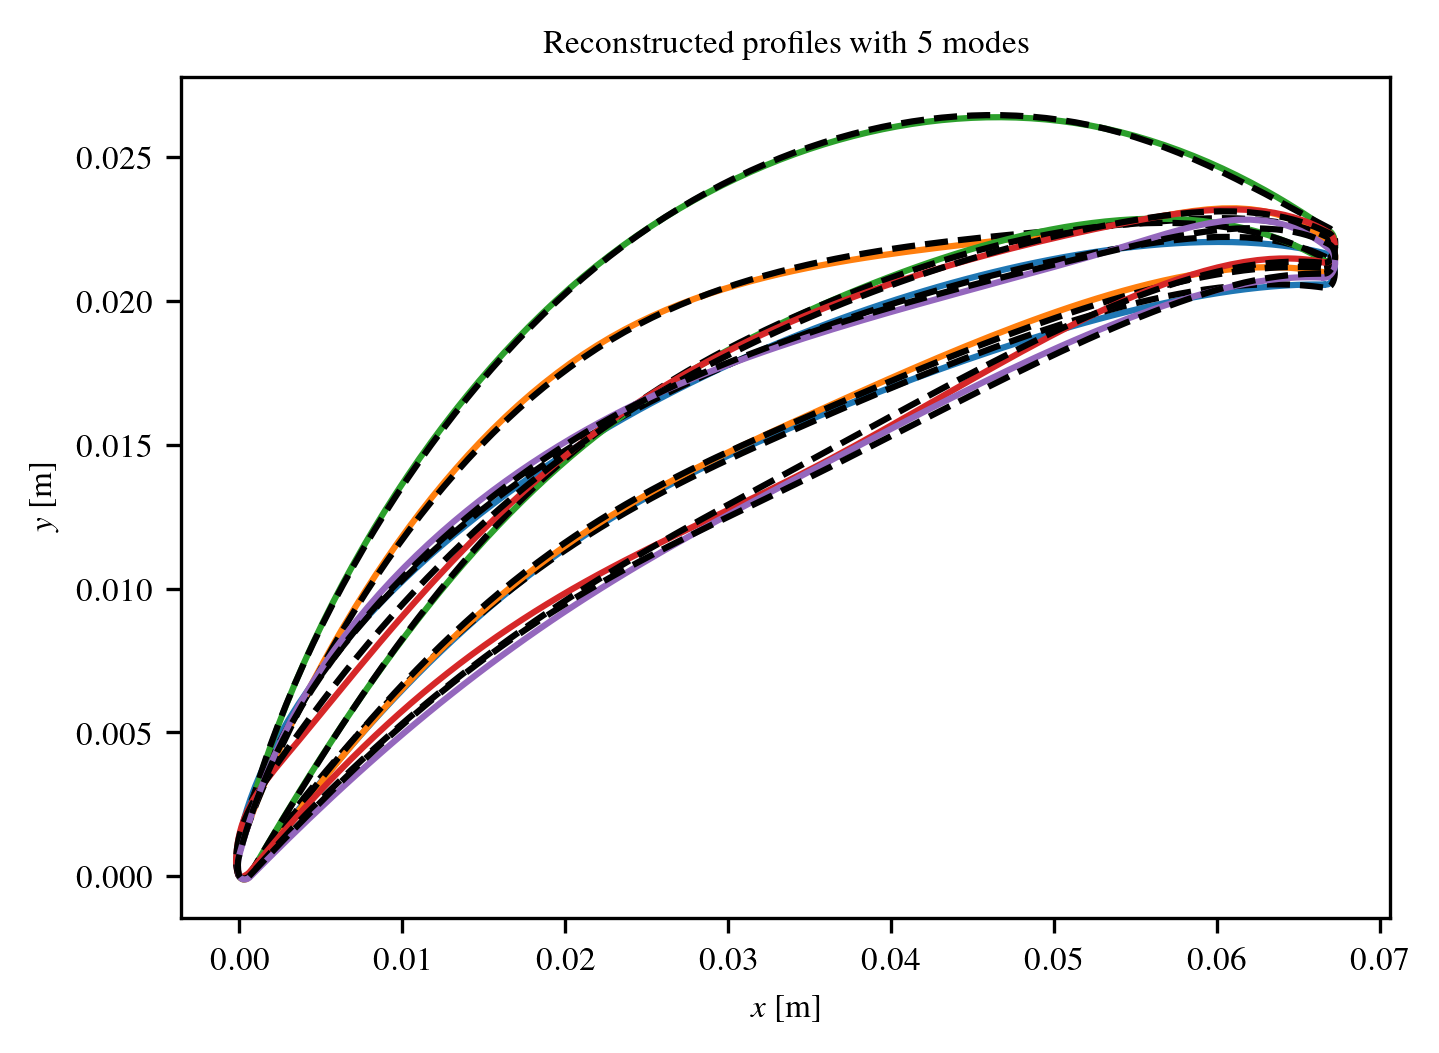

In [18]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Times",
    "figure.dpi": 300,
    "font.size": 8,
    'legend.fontsize': 8, 
    "axes.titlesize": 8,
    "axes.labelsize": 8
})
fig, ax = plt.subplots(figsize=(5.2, 3.64))
for ii in range(5):
    idx = random.randint(0, len(profiles) - 1)
    ax.plot(profiles[idx][:, 0], S[:, idx])
    ax.plot(profiles[idx][:, 0], D_tilde[:, idx], linestyle="dashed", color="k")
ax.set(xlabel="$x$ [m]", ylabel="$y$ [m]", title=f"Reconstructed profiles with {nmode} modes")

The cumulative energy percentage is computed given `nmode`

In [19]:
for nn in range(1, nmode + 1):
    print(f"{nn} mode energy percentage = {np.sum(eigenvalues[-nn:]) / sum(eigenvalues) * 100} %")

1 mode energy percentage = 69.01368036131366 %
2 mode energy percentage = 89.17652855399551 %
3 mode energy percentage = 94.87749615394456 %
4 mode energy percentage = 98.00060062995689 %
5 mode energy percentage = 98.85619926111157 %


The geometric modes (a) and the energy and error (b) are plotted

 <>:26: SyntaxWarning:invalid escape sequence '\%'
 <>:26: SyntaxWarning:invalid escape sequence '\%'
 /tmp/ipykernel_1045243/4089054718.py:26: SyntaxWarning:invalid escape sequence '\%'


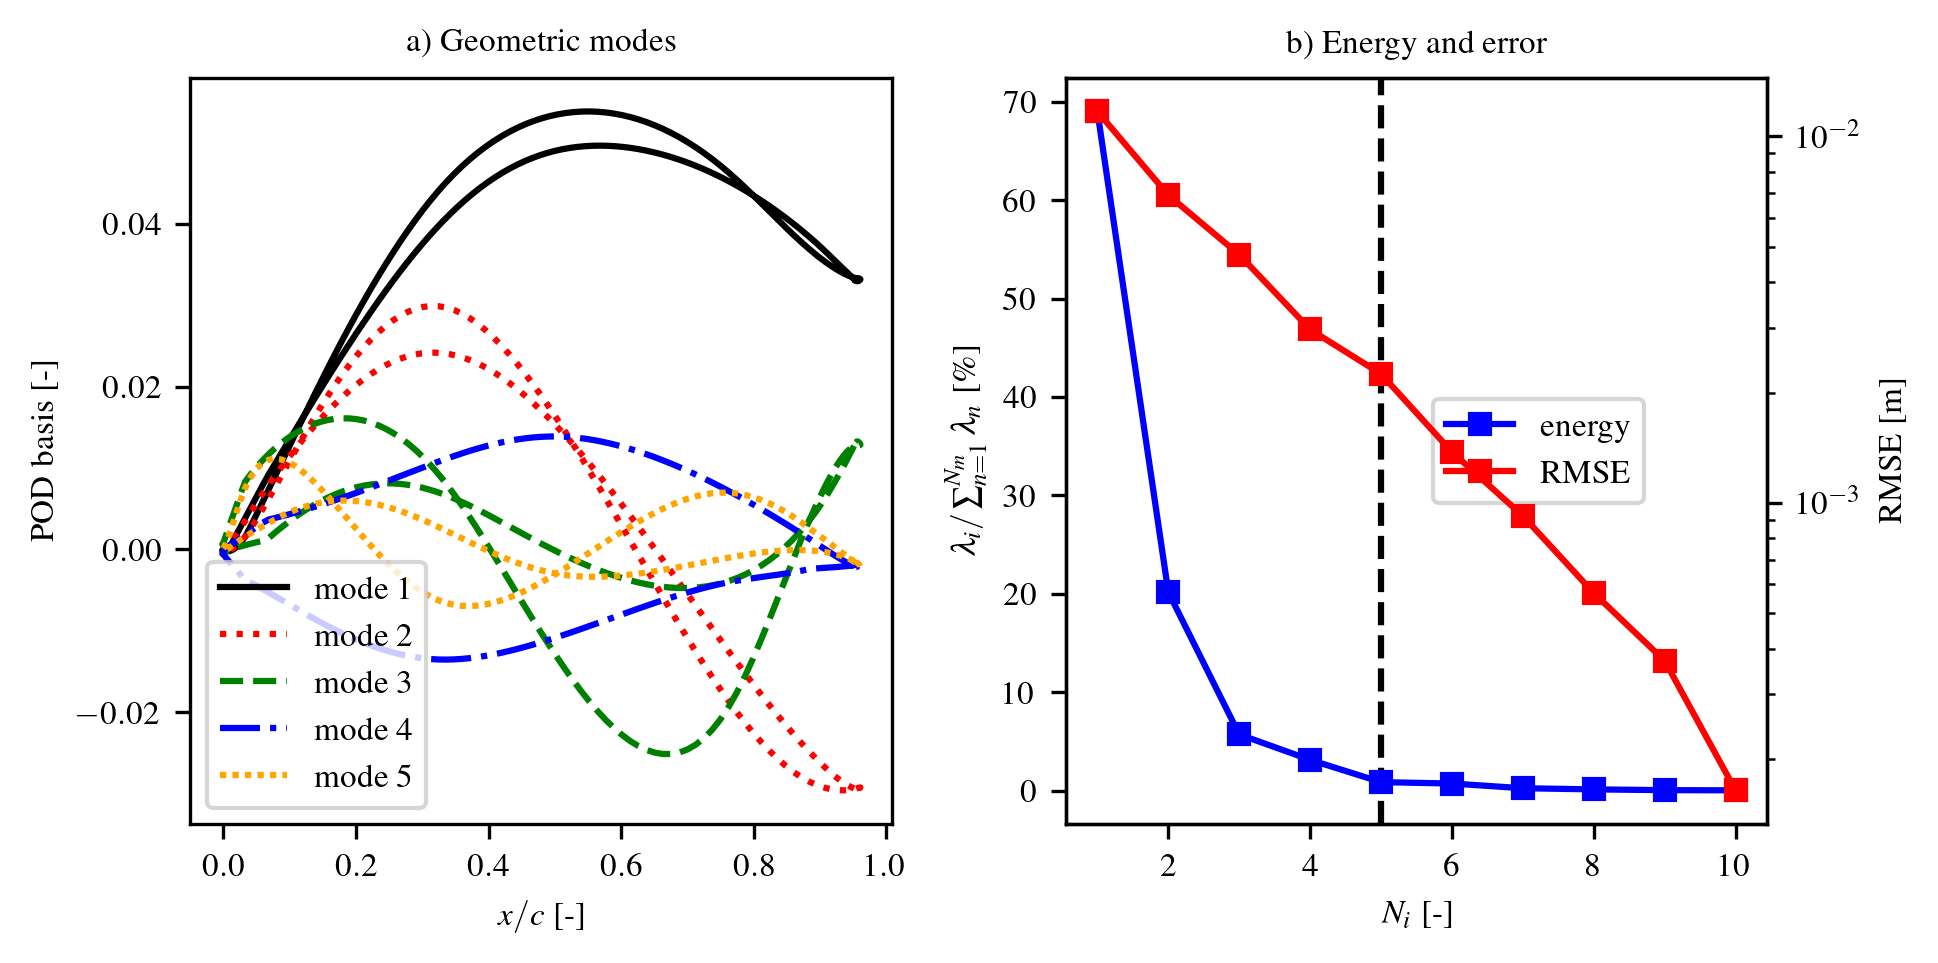

In [20]:
eigen_nrj = []
error = []
color = ["k", "r", "g", "b", "orange", "darkviolet"]
ls = ["solid", "dotted", "dashed", "dashdot", (0, (1, 1)), (0, (2, 1))]
fig = plt.figure(figsize=(6.5, 3.25))
fig.subplots_adjust(hspace=0.25)
ax1 = plt.subplot(1, 2, 1)  # geom. modes
ax2 = plt.subplot(1, 2, 2)  # POD eigenvalue energy
for nn in range(1, nmode + 1):
    # ax1
    ax1.plot(ffd.pts[:, 0] / 0.07, phi_tilde[:, -nn], label=f"mode {nn}", color=color[nn - 1], linestyle=ls[nn - 1])
for nn in range(1, ncontrol + 1):
    phi_tilde_tmp = phi[:, -nn:]
    V_tilde_inv_tmp = np.linalg.inv(eigenvectors)[-nn:, :]
    D_tilde_tmp = S_mean[:, None] + np.matmul(phi_tilde_tmp, V_tilde_inv_tmp)
    # ax2
    eigen_nrj.append(eigenvalues[-nn] / np.sum(eigenvalues) * 100)
    error.append(np.sqrt(np.sum([np.sum((y_true - y_pred)**2) for y_true, y_pred in zip(S.transpose(), D_tilde_tmp.transpose())]) / nprofile))
ax2.axvline(nmode, color="k", linestyle="dashed")
ax2.plot(range(1, len(eigen_nrj) + 1), eigen_nrj, color="blue", marker="s", ms=5, label="energy")
ax22 = ax2.twinx()  # instantiate a second Axes that shares the same x-axis
ax22.plot(range(1, len(error) + 1), error, color="red", marker="s", ms=5, label="RMSE")
ax22.set_yscale("log")
ax1.set(xlabel="$x / c$ [-]", ylabel="POD basis [-]", title="a) Geometric modes")
ax1.legend(loc="lower left")
ax2.set(xlabel="$N_i$ [-]", ylabel="$\\lambda_i / \\sum_{n=1}^{N_m} \\lambda_n$ [\%]", title="b) Energy and error")
ax22.set(ylabel="RMSE [m]")
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax22.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="center left", bbox_to_anchor=(0.5, 0.5))
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "POD.pdf"), bbox_inches="tight")
plt.show()

The POD boundaries are inferred from the modal coefficient min/max values

In [21]:
l_bound = np.array([min(v) for v in V_tilde_inv])
u_bound = np.array([max(v) for v in V_tilde_inv])

In [22]:
y_min = S_mean + np.sum(phi_tilde * np.array(l_bound), axis=1)
y_max = S_mean + np.sum(phi_tilde * np.array(u_bound), axis=1)

The non-correspondence between the POD and FFD boundaries is illustrated

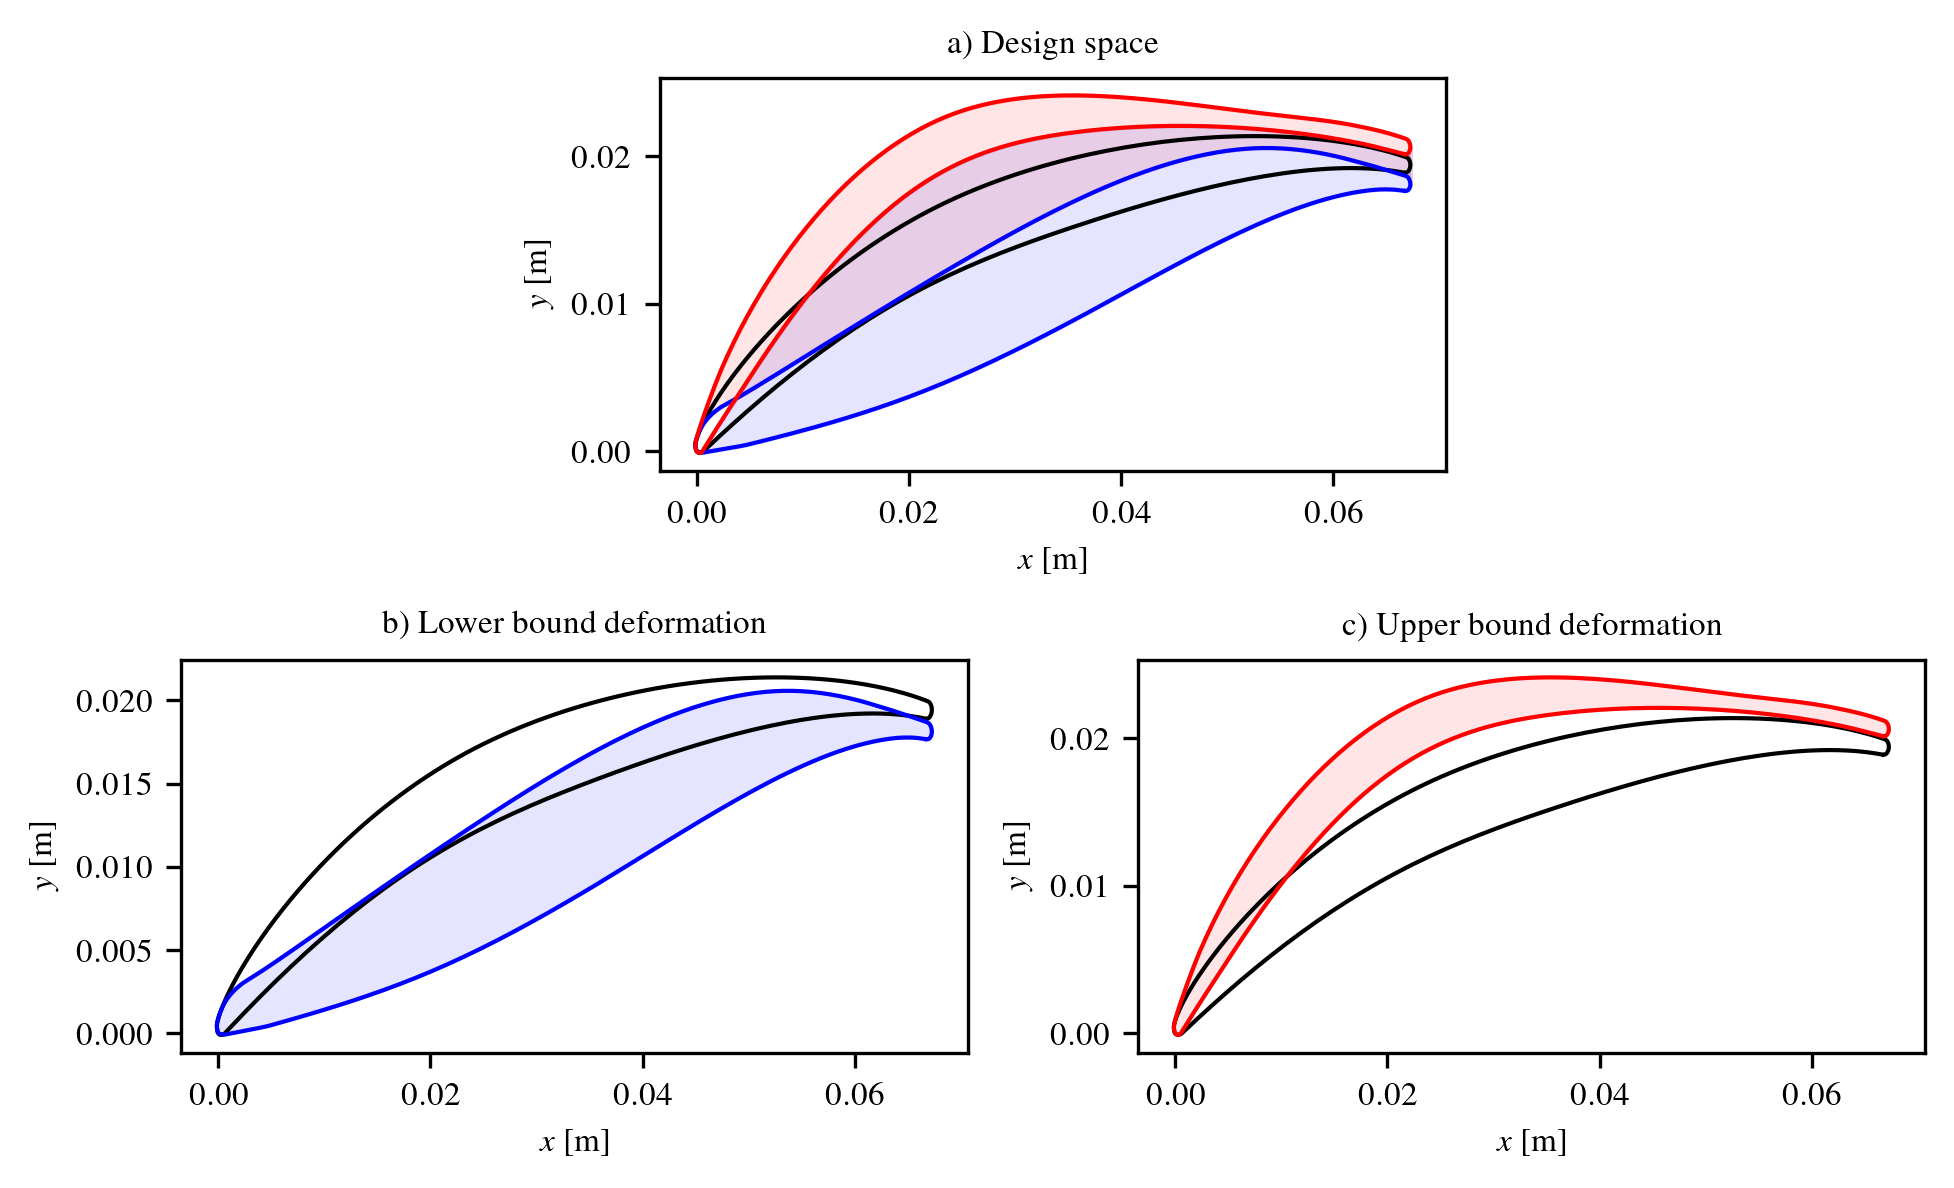

In [23]:
# POD
upper_min, lower_min = split_profile(np.column_stack((ffd.pts[:, 0], y_min)))
upper_max, lower_max = split_profile(np.column_stack((ffd.pts[:, 0], y_max)))
upper_pro, lower_pro = split_profile(ffd.pts)
# Figure
fig = plt.figure(figsize=(6.5, 4))
fig.subplots_adjust(hspace=1.5, wspace=2)
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = plt.subplot(gs[0, 1:3])
ax2 = plt.subplot(gs[1, :2])
ax3 = plt.subplot(gs[1, 2:])
# ax1
ax1.plot(ffd.pts[:, 0], ffd.pts[:, 1], label="baseline profile", color="k", linewidth=1)
ax1.plot(ffd.pts[:, 0], y_min, label=f"min profile", color="b", linewidth=1)
ax1.plot(ffd.pts[:, 0], y_max, label=f"max profile", color="r", linewidth=1)
ax1.fill_between(lower_min[:, 0], lower_min[:, 1], lower_max[:, 1], color="b", alpha=0.1)
ax1.fill_between(upper_max[:, 0], upper_min[:, 1], upper_max[:, 1], color="r", alpha=0.1)
# ax1.plot(max_profile[:, 0], max_profile[:, 1], label=f"ffd min profile", color="b", linewidth=1, linestyle="dashed")
# ax1.plot(min_profile[:, 0], min_profile[:, 1], label=f"ffd min profile", color="r", linewidth=1, linestyle="dashed")
# ax2
ax2.plot(ffd.pts[:, 0], ffd.pts[:, 1], label="baseline profile", color="k", linewidth=1)
ax2.plot(ffd.pts[:, 0], y_min, label=f"min profile", color="b", linewidth=1)
ax2.fill(ffd.pts[:, 0], y_min, label=f"min profile", color="b", alpha=0.1)
# ax2.plot(max_profile[:, 0], max_profile[:, 1], label=f"ffd min profile", color="b", linewidth=1, linestyle="dashed")
# ax3
ax3.plot(ffd.pts[:, 0], ffd.pts[:, 1], label="baseline profile", color="k", linewidth=1)
ax3.plot(ffd.pts[:, 0], y_max, label=f"max profile", color="r", linewidth=1)
ax3.fill(ffd.pts[:, 0], y_max, label=f"max profile", color="r", alpha=0.1)
# ax3.plot(min_profile[:, 0], min_profile[:, 1], label=f"ffd min profile", color="r", linewidth=1, linestyle="dashed")
# plot lattice grid
ax1.set(xlabel="$x$ [m]", ylabel="$y$ [m]", title="a) Design space")
ax2.set(xlabel="$x$ [m]", ylabel="$y$ [m]", title="b) Lower bound deformation")
ax3.set(xlabel="$x$ [m]", ylabel="$y$ [m]", title="c) Upper bound deformation")
# legend and display
plt.tight_layout()

The non-conservation of the FFD maximal deformations is illustrated 

In [24]:
new_bounds = (l_bound, u_bound)
new_sampler = qmc.LatinHypercube(d=nmode, seed=seed)
new_sample = new_sampler.random(n=100)
scaled_sample = qmc.scale(new_sample, *new_bounds)
print(new_bounds)

(array([-0.08848299, -0.10176003, -0.08298036, -0.08694098, -0.09126555]), array([0.08280334, 0.07385498, 0.080811  , 0.07443847, 0.08230332]))


In [ ]:
fig, ax = plt.subplots(figsize=(3.15, 2))
for ss_id, ss in enumerate(scaled_sample):
    y = S_mean + np.sum(phi_tilde * ss, axis=1)
    if ss_id == 0:
        ax.plot(ffd.pts[:, 0], y, linestyle="solid", color="lightgrey", linewidth=0.5, label=" random POD profiles")
    else:
        ax.plot(ffd.pts[:, 0], y, linestyle="solid", color="lightgrey", linewidth=0.5)
ax.plot(min_profile[:, 0], min_profile[:, 1], color="k", linewidth=1, linestyle="dashed", label="min/max FFD profiles")
ax.plot(max_profile[:, 0], max_profile[:, 1], color="k", linewidth=1, linestyle="dashed")
ax.legend()
ax.set(xlabel="$x$ [m]", ylabel="$y$ [m]")
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "POD_profiles.pdf"), bbox_inches="tight")
plt.show()

The latent space distributions are plotted

**Note**: if the number of modes `nmode` is changed, the sub-figure structure must be adapted

In [25]:
latent_space = V_tilde_inv

[Text(0.5, 0, '$\\alpha_5$ [-]'),
 Text(0, 0.5, '$N$ [-]'),
 Text(0.5, 1.0, 'd) distribution /dim 4')]

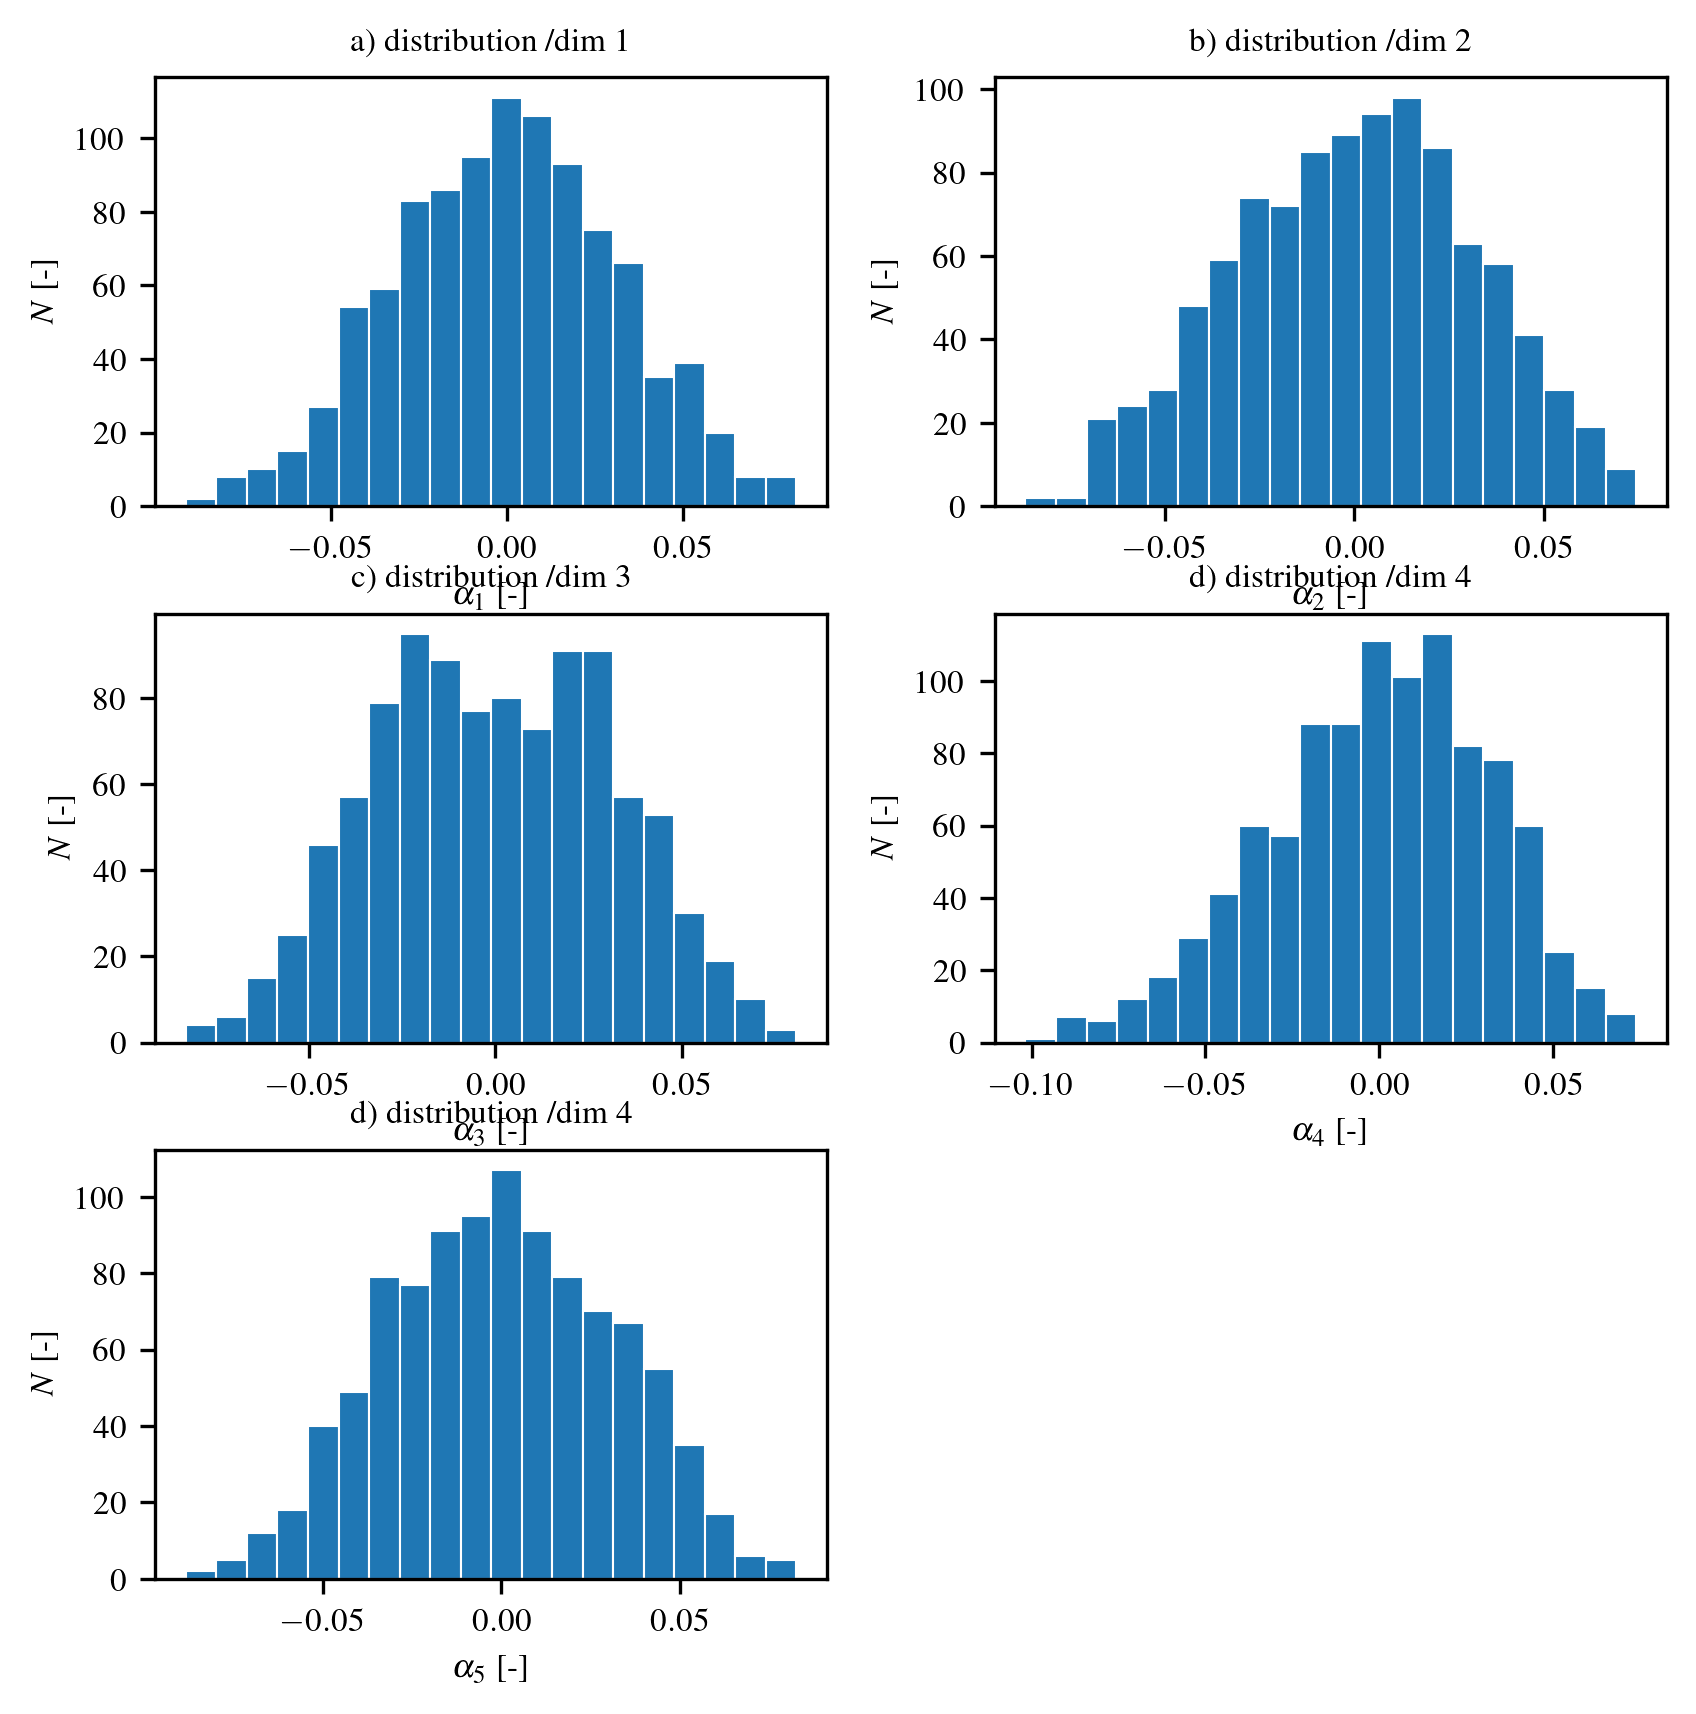

In [27]:
fig = plt.figure(figsize=(6.5, 6.5))
fig.subplots_adjust(hspace=0.25, wspace=0.25)
ax1 = plt.subplot(3, 2, 1)  # dim 1
ax2 = plt.subplot(3, 2, 2)  # dim 2
ax3 = plt.subplot(3, 2, 3)  # dim 3
ax4 = plt.subplot(3, 2, 4)  # dim 4
ax5 = plt.subplot(3, 2, 5)  # dim 5
ax1.hist(latent_space[-1, :], bins=20, linewidth=0.5, edgecolor="white")
ax1.set(xlabel="$\\alpha_1$ [-]", ylabel="$N$ [-]", title="a) distribution /dim 1")
ax2.hist(latent_space[-2, :], bins=20, linewidth=0.5, edgecolor="white")
ax2.set(xlabel="$\\alpha_2$ [-]", ylabel="$N$ [-]", title="b) distribution /dim 2")
ax3.hist(latent_space[-3, :], bins=20, linewidth=0.5, edgecolor="white")
ax3.set(xlabel="$\\alpha_3$ [-]", ylabel="$N$ [-]", title="c) distribution /dim 3")
ax4.hist(latent_space[-4, :], bins=20, linewidth=0.5, edgecolor="white")
ax4.set(xlabel="$\\alpha_4$ [-]", ylabel="$N$ [-]", title="d) distribution /dim 4")
ax5.hist(latent_space[-5, :], bins=20, linewidth=0.5, edgecolor="white")
ax5.set(xlabel="$\\alpha_5$ [-]", ylabel="$N$ [-]", title="d) distribution /dim 4")